
# Generador de Rutinas de ASCEND — Versión de Producción (Regla de Negocio)

## Por qué una regla de negocio y no un modelo de ML

Ya lo probamos con similitud coseno primero (ver el notebook
`3.3 Recomendador_Similitud_Coseno.ipynb`) y **no funcionó bien**: el
producto punto de la similitud coseno crece con la dificultad sin
límite (nunca penaliza "pasarse" de dificultad). La solución
no fue un modelo más sofisticado — fue cambiar la métrica de similitud
por una de **distancia** (que sí castiga pasarse Y quedarse corto).

## Las piezas del pipeline

1. Filtrado por equipo disponible.

2. Rango de dificultad tolerable, según el perfil del usuario (viene de
   los clusters de composición física — ver notebook de clustering).

3. Tope de dificultad progresivo. 

4. Ajuste por feedback dl usuario (rutinas marcadas "fácil"/"difícil").

5. Balance de zonas musculares — corrige el objetivo declarado con lo
   que el usuario REALMENTE ha entrenado.

6. La función de score (zona + distancia de dificultad).

7. Selección final: alternar zonas + penalización suave por repetición.

8. El menú completo: varias rutinas candidatas.


In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 4.5)

VERDE_PRIMARIO = "#006a20"
VERDE_MEDIO = "#20a04e"
VERDE_SUAVE = "#8ec899"
CASI_NEGRO = "#141d16"

catalogo = pd.read_parquet("../Data/processed/exercises_catalog_spanish_version.parquet")
# El generador de rutinas usa un score continuo de dificultad (ver nota
# en el EDA sobre 'score_demo' como proxy de la clasificación fina real).
catalogo = catalogo.rename(columns={"score_demo": "dificultad_continua"})
print(f"Catálogo cargado: {len(catalogo)} ejercicios")


Catálogo cargado: 1324 ejercicios



## 1. Zonas musculares y objetivos — las piezas base

Cada objetivo declarado por el usuario (Bajar de peso, Ganar músculo,
etc.) tiene un "perfil ideal" de cuánto debería pesar cada zona muscular
en la rutina, y en qué punto de su rango de dificultad debería ubicarse
(0 = extremo bajo del rango, 1 = extremo alto). Esto es una **decisión
de producto**, no algo ajustado estadísticamente — documentado así a
propósito para que quede claro qué parte del sistema es "diseño" y qué
parte es "aprendido".


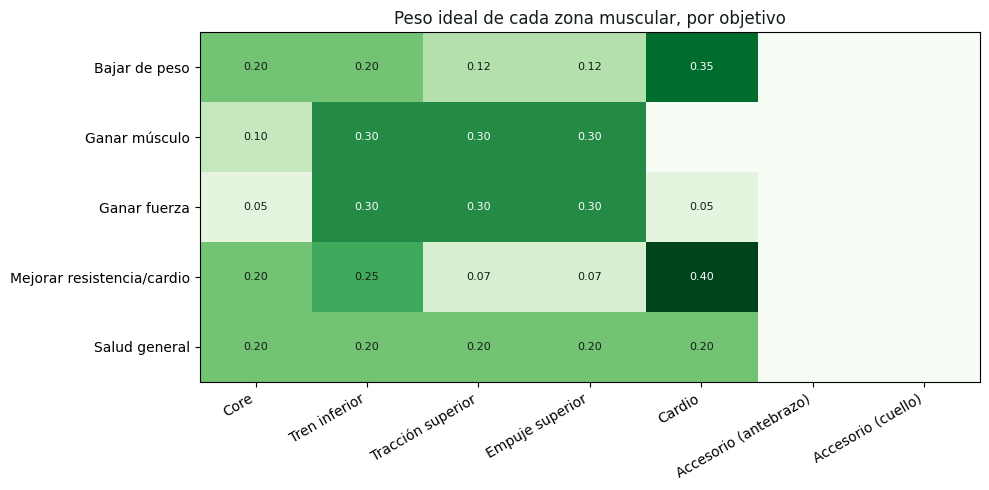

In [13]:

ZONAS_MUSCULARES = [
    "Core", "Tren inferior", "Tracción superior", "Empuje superior",
    "Cardio", "Accesorio (antebrazo)", "Accesorio (cuello)",
]

PERFILES_OBJETIVO = {
    "Bajar de peso": {
        "zonas_ideal": {"Cardio": 0.35, "Core": 0.20, "Tren inferior": 0.20,
                         "Empuje superior": 0.125, "Tracción superior": 0.125},
        "posicion_en_rango": 0.35,
    },
    "Ganar músculo": {
        "zonas_ideal": {"Empuje superior": 0.3, "Tracción superior": 0.3, "Tren inferior": 0.3,
                         "Core": 0.1},
        "posicion_en_rango": 0.55,
    },
    "Ganar fuerza": {
        "zonas_ideal": {"Empuje superior": 0.3, "Tracción superior": 0.3, "Tren inferior": 0.3,
                         "Core": 0.05, "Cardio": 0.05},
        "posicion_en_rango": 0.8,
    },
    "Mejorar resistencia/cardio": {
        "zonas_ideal": {"Cardio": 0.4, "Tren inferior": 0.25, "Core": 0.2,
                         "Empuje superior": 0.075, "Tracción superior": 0.075},
        "posicion_en_rango": 0.45,
    },
    "Salud general": {
        "zonas_ideal": {"Empuje superior": 0.2, "Tracción superior": 0.2, "Tren inferior": 0.2,
                         "Core": 0.2, "Cardio": 0.2},
        "posicion_en_rango": 0.5,
    },
}

REPS_RANGE_POR_OBJETIVO = {
    "Bajar de peso": (15, 20), "Ganar músculo": (10, 12), "Ganar fuerza": (5, 8),
    "Mejorar resistencia/cardio": (15, 25), "Salud general": (10, 15),
}
SERIES_POR_OBJETIVO = {
    "Bajar de peso": (2, 3), "Ganar músculo": (3, 4), "Ganar fuerza": (4, 5),
    "Mejorar resistencia/cardio": (2, 3), "Salud general": (3, 3),
}

# Visualización: qué tanto peso le da cada objetivo a cada zona
fig, ax = plt.subplots(figsize=(10, 5))
objetivos = list(PERFILES_OBJETIVO.keys())
matriz = np.array([[PERFILES_OBJETIVO[o]["zonas_ideal"].get(z, 0) for z in ZONAS_MUSCULARES] for o in objetivos])
im = ax.imshow(matriz, cmap="Greens", aspect="auto")
ax.set_xticks(range(len(ZONAS_MUSCULARES)))
ax.set_xticklabels(ZONAS_MUSCULARES, rotation=30, ha="right")
ax.set_yticks(range(len(objetivos)))
ax.set_yticklabels(objetivos)
for i in range(len(objetivos)):
    for j in range(len(ZONAS_MUSCULARES)):
        v = matriz[i, j]
        if v > 0:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                     color="white" if v > 0.25 else CASI_NEGRO, fontsize=8)
ax.set_title("Peso ideal de cada zona muscular, por objetivo", color=CASI_NEGRO)
plt.tight_layout()
plt.show()


**Insights de las Reglas de Negocio:**

- **Ningún objetivo asigna peso a "Accesorio (antebrazo)" ni "Accesorio (cuello)"** El generador simplemente no las contempla como parte de ninguna rutina orientada a objetivo por la falta de ejercicios.

- **"Ganar músculo" y "Ganar fuerza" son los más concentrados:** reparten el 90% del peso entre solo 3 zonas (Tren inferior, Tracción y Empuje superior), coherente con objetivos de hipertrofia/fuerza.

- **"Mejorar resistencia/cardio" es el más polarizado:** Es el objetivo con el perfil menos balanceado de los 5.

- **"Salud general" es, por diseño, perfectamente parejo** El único objetivo pensado explícitamente para no favorecer ninguna zona sobre otra.

**Trabajo futuro:** dado que el catálogo ya tiene ejercicios reales de antebrazo y cuello (aunque pocos — 37 y 2 respectivamente, según el EDA), valdría la pena ampliar ese inventario y luego sí incorporar esas zonas a `PERFILES_OBJETIVO` con un peso pequeño pero no nulo.


## 2. Rango de dificultad tolerable por perfil (cluster) y tope progresivo

El cluster de composición física del usuario, da
un rango de dificultad tolerable inicial, Pero ese rango nunca es un
techo permanente. Un segundo mecanismo, el **tope progresivo**, empieza
conservador para cualquier usuario, sube con cada rutina completada.


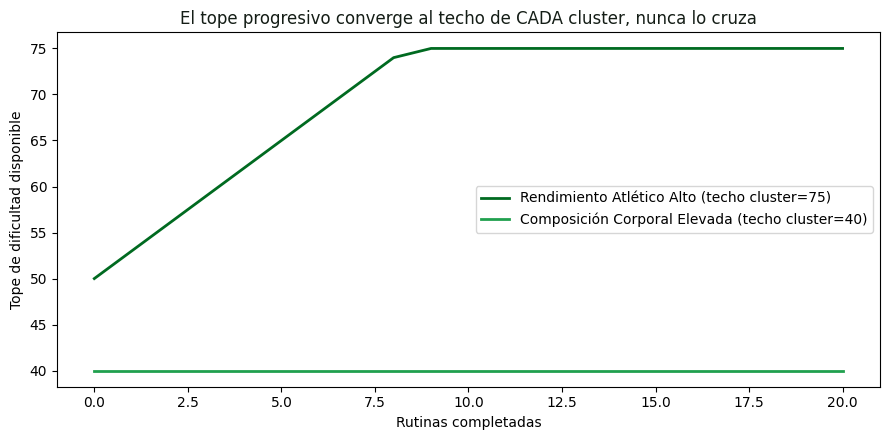

In [14]:

RANGO_DIFICULTAD_POR_CLUSTER = {
    "Rendimiento Atlético Alto": (25, 75),
    "Contextura Ligera, Fuerza Limitada": (5, 50),
    "Contextura Ligera, Buena Eficiencia": (10, 60),
    "Composición Corporal Elevada": (5, 40),
}
RANGO_DEFAULT_SIN_CLASIFICACION = (10, 45)

TOPE_DIFICULTAD_INICIAL = 50.0
INCREMENTO_TOPE_POR_RUTINA = 3.0
TOPE_DIFICULTAD_ABSOLUTO = 100.0

PUNTOS_POR_FACIL = 1.0
PUNTOS_POR_DIFICIL = 2.0  # asimetría: baja más rápido de lo que sube, esto para penalizar más el sentirse mal con la rutina y se ajuste más rápido
                            # El premiar el sentirlo fácil por más valor podría generar una sensación de dificultad mayor para el usuario y perjudicar la adopción de al app


def calcular_ajuste_dificultad(historial: list[dict] | None) -> float:
    '''+1 punto por cada rutina marcada 'fácil', -2 por cada 'difícil'.
    'bien' no mueve nada. La asimetría vive en la MAGNITUD, no en el
    mecanismo — ambos se aplican de inmediato, uno por uno.'''
    if not historial:
        return 0.0
    n_facil = sum(1 for h in historial if h.get("feedback_dificultad") == "facil")
    n_dificil = sum(1 for h in historial if h.get("feedback_dificultad") == "dificil")
    return (n_facil * PUNTOS_POR_FACIL) - (n_dificil * PUNTOS_POR_DIFICIL)


def obtener_techo_cluster(nivel_cluster_nombre: str | None, historial: list[dict] | None) -> float:
    '''El techo 'real' a usar — el rango del cluster es el punto de
    partida, pero un ajuste POSITIVO por feedback puede expandirlo más
    allá (nunca lo reduce por debajo del techo original del cluster).'''
    rango = RANGO_DIFICULTAD_POR_CLUSTER.get(nivel_cluster_nombre, RANGO_DEFAULT_SIN_CLASIFICACION)
    expansion = max(calcular_ajuste_dificultad(historial), 0.0)
    return min(rango[1] + expansion, TOPE_DIFICULTAD_ABSOLUTO)


def calcular_tope_dificultad(nivel_cluster_nombre: str | None, historial: list[dict] | None) -> float:
    '''Filtro DURO sobre los candidatos: nunca se negocia. Empieza en
    TOPE_DIFICULTAD_INICIAL y sube 3 puntos por cada rutina completada,
    sin superar nunca el techo del cluster (ya expandido por feedback).'''
    techo = obtener_techo_cluster(nivel_cluster_nombre, historial)
    n_completadas = len([h for h in (historial or []) if h.get("dificultad_promedio_rutina") is not None])
    tope = TOPE_DIFICULTAD_INICIAL + INCREMENTO_TOPE_POR_RUTINA * n_completadas
    return min(max(tope, TOPE_DIFICULTAD_INICIAL), techo, TOPE_DIFICULTAD_ABSOLUTO)


# Demostración: cómo evoluciona el tope para 2 usuarios distintos, según
# cuántas rutinas han completado (con feedback neutral, para aislar solo
# el efecto de la progresión por cantidad de rutinas).
rutinas_completadas = list(range(0, 21))
historiales_simulados = [[{"dificultad_promedio_rutina": 30} for _ in range(n)] for n in rutinas_completadas]

tope_atletico = [calcular_tope_dificultad("Rendimiento Atlético Alto", h) for h in historiales_simulados]
tope_ligero = [calcular_tope_dificultad("Composición Corporal Elevada", h) for h in historiales_simulados]

fig, ax = plt.subplots()
ax.plot(rutinas_completadas, tope_atletico, color=VERDE_PRIMARIO, linewidth=2, label="Rendimiento Atlético Alto (techo cluster=75)")
ax.plot(rutinas_completadas, tope_ligero, color=VERDE_MEDIO, linewidth=2, label="Composición Corporal Elevada (techo cluster=40)")
ax.set_xlabel("Rutinas completadas")
ax.set_ylabel("Tope de dificultad disponible")
ax.set_title("El tope progresivo converge al techo de CADA cluster, nunca lo cruza", color=CASI_NEGRO)
ax.legend()
plt.tight_layout()
plt.show()



Ambos usuarios arrancan igual (50/100, el tope inicial
parejo para todos), pero cada uno converge a un techo distinto según su cluster — el de "Rendimiento Atlético Alto" sigue subiendo hasta 75,
mientras que el de "Composición Corporal Elevada" se queda topado en 40 sin importar cuántas rutinas complete (a menos que además acumule
feedback positivo, que expande ese techo).


## 3. La función de score — el corazón del sistema

Aquí está la pieza que reemplazó a la similitud coseno. El score de
cada ejercicio candidato es una mezcla de dos señales:

- **Qué tan relevante es su zona** para el balance actual (objetivo +
  déficit de entrenamiento real).
- **Qué tan CERCA está su dificultad del nivel objetivo** — no qué tan
  alta. Esta es la diferencia clave frente a la similitud coseno: aquí
  se usa **distancia absoluta**, que castiga tanto pasarse como
  quedarse corto.


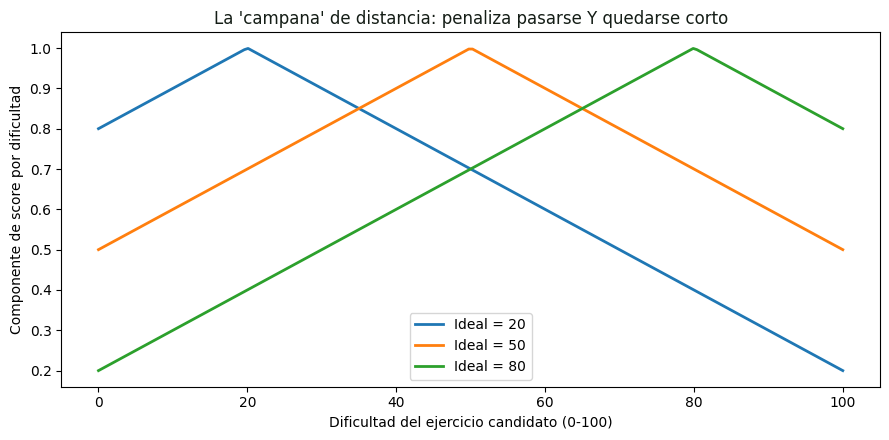

In [15]:

ALPHA_ZONA_VS_DIFICULTAD = 0.55  # 1.0 = ignora dificultad, 0.0 = ignora zona


def calcular_scores(df: pd.DataFrame, pesos_zonas: dict, dificultad_ideal_norm: float) -> pd.Series:
    '''
    Score = ALPHA * relevancia_de_zona + (1-ALPHA) * (1 - |dificultad_normalizada - dificultad_ideal|)

    El segundo término es una CAMPANA invertida centrada en la dificultad
    ideal: vale 1.0 exactamente en el nivel objetivo, y decae conforme el
    ejercicio se aleja en cualquier dirección (más fácil O más difícil).
    Esto es justo lo que la similitud coseno no podía hacer.
    '''
    score_zona = df["zona_muscular"].map(pesos_zonas).fillna(0.0)
    d_norm = df["score_llm"] / 100.0
    ajuste_dificultad = 1.0 - (d_norm - dificultad_ideal_norm).abs()
    return ALPHA_ZONA_VS_DIFICULTAD * score_zona + (1 - ALPHA_ZONA_VS_DIFICULTAD) * ajuste_dificultad


# Visualización del término de dificultad en aislado (pesos_zonas fijo en 1
# para que solo se vea la forma de la "campana" de distancia)
dificultades_posibles = np.linspace(0, 100, 200)
for dificultad_ideal in [20, 50, 80]:
    ajuste = 1.0 - np.abs(dificultades_posibles / 100 - dificultad_ideal / 100)
    plt.plot(dificultades_posibles, ajuste, label=f"Ideal = {dificultad_ideal}", linewidth=2)

plt.xlabel("Dificultad del ejercicio candidato (0-100)")
plt.ylabel("Componente de score por dificultad")
plt.title("La 'campana' de distancia: penaliza pasarse Y quedarse corto", color=CASI_NEGRO)
plt.legend()
plt.tight_layout()
plt.show()



**Esta gráfica es la explicación visual de por qué se abandonó la
similitud coseno.** Con distancia absoluta, el score de dificultad tiene
un pico exactamente en el nivel ideal y cae simétricamente a los lados —
un ejercicio de dificultad 90 cuando lo ideal es 20 recibe un score
CASTIGADO, no premiado. Con similitud coseno (producto punto), esa
misma situación habría dado un score más alto mientras más alta fuera la
dificultad del candidato, sin importar el ideal — por eso siempre
terminaba recomendando lo más difícil disponible (lo replicamos y lo
demostramos con números reales en el notebook de similitud coseno).



## 4. Balance de zonas — corrige el objetivo con lo que el usuario REALMENTE entrena

Sin esto, alguien con objetivo "Ganar fuerza" que ya hizo 5 rutinas de
empuje/tracción seguiría recibiendo más empuje/tracción, aunque tenga el
core totalmente abandonado. El balance calcula un "déficit de
entrenamiento" (zonas trabajadas menos de lo que les tocaría en
proporción pareja) y lo mezcla con el perfil del objetivo.


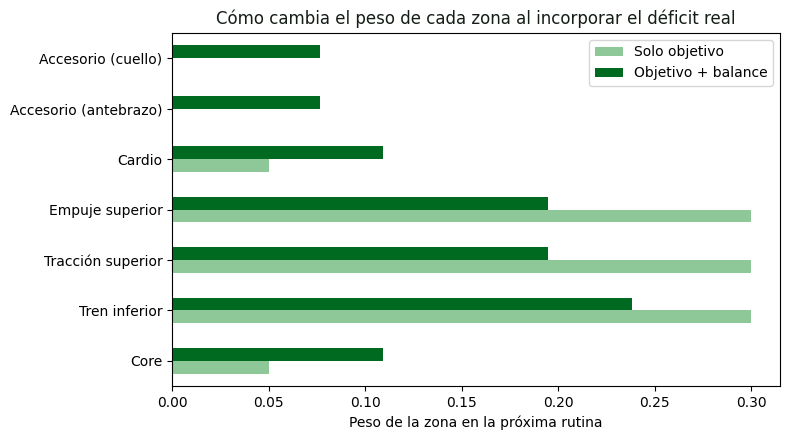

,Solo objetivo,Objetivo + balance
Core,0.05,0.109
Tren inferior,0.30,0.238
Tracción superior,0.30,0.195
Empuje superior,0.30,0.195
Cardio,0.05,0.109
Accesorio (antebrazo),0.00,0.077
Accesorio (cuello),0.00,0.077


In [16]:

PESO_BALANCE_ZONAS_DEFAULT = 0.35  # 0 = ignora el balance, 1 = ignora el objetivo


def pesos_zonas_balanceados(objetivo: str, frecuencia_zonas: dict | None, peso_balance: float = PESO_BALANCE_ZONAS_DEFAULT) -> dict:
    perfil = PERFILES_OBJETIVO.get(objetivo, PERFILES_OBJETIVO["Salud general"])
    pesos_objetivo = {z: perfil["zonas_ideal"].get(z, 0.0) for z in ZONAS_MUSCULARES}

    total_entrenado = sum((frecuencia_zonas or {}).values())
    if total_entrenado == 0:
        return pesos_objetivo  # sin historial todavía, no hay nada que balancear

    proporcion_justa = 1.0 / len(ZONAS_MUSCULARES)
    deficit = {z: max(0.0, proporcion_justa - (frecuencia_zonas.get(z, 0) / total_entrenado)) for z in ZONAS_MUSCULARES}
    suma_deficit = sum(deficit.values())
    deficit_normalizado = (
        {z: v / suma_deficit for z, v in deficit.items()} if suma_deficit > 0
        else {z: proporcion_justa for z in ZONAS_MUSCULARES}
    )

    pesos_finales = {
        z: (1 - peso_balance) * pesos_objetivo[z] + peso_balance * deficit_normalizado[z]
        for z in ZONAS_MUSCULARES
    }
    suma_final = sum(pesos_finales.values())
    return {z: v / suma_final for z, v in pesos_finales.items()} if suma_final > 0 else pesos_objetivo


# Demostración: usuario con objetivo "Ganar fuerza" que ha entrenado
# Empuje/Tracción mucho, pero casi nada de Core ni Tren inferior.
frecuencia_ejemplo = {
    "Empuje superior": 8, "Tracción superior": 7, "Tren inferior": 1,
    "Core": 0, "Cardio": 0, "Accesorio (antebrazo)": 0, "Accesorio (cuello)": 0,
}

pesos_sin_balance = pesos_zonas_balanceados("Ganar fuerza", None)
pesos_con_balance = pesos_zonas_balanceados("Ganar fuerza", frecuencia_ejemplo)

comparacion = pd.DataFrame({"Solo objetivo": pesos_sin_balance, "Objetivo + balance": pesos_con_balance})
comparacion.plot(kind="barh", figsize=(8, 4.5), color=[VERDE_SUAVE, VERDE_PRIMARIO])
plt.xlabel("Peso de la zona en la próxima rutina")
plt.title("Cómo cambia el peso de cada zona al incorporar el déficit real", color=CASI_NEGRO)
plt.tight_layout()
plt.show()

comparacion.round(3)



Core y Tren inferior suben de peso frente al "solo
objetivo" — el sistema detecta que el usuario las ha descuidado y empuja la próxima rutina hacia ahí, sin ignorar por completo que el
objetivo real sigue siendo "Ganar fuerza" (Empuje/Tracción no caen a
cero, solo bajan un poco).



## 5. Selección final: alternar zonas + penalización suave por repetición

Con los scores ya calculados, la selección greedy alterna zonas
musculares consecutivas (para que la rutina no repita la misma zona dos
veces seguidas) y aplica una penalización pequeña (no una eliminación)
a los ejercicios usados en rutinas recientes — variedad es una
preferencia suave, nunca le gana a encontrar la dificultad correcta.


In [17]:

PENALIZACION_ROTACION = 0.08


def generar_rutina(
    equipo_disponible: list[str], objetivo: str, nivel_cluster_nombre: str | None,
    historial: list[dict] | None = None, n_ejercicios: int = 8,
    desplazamiento_dificultad: float = 0.0, peso_balance: float = PESO_BALANCE_ZONAS_DEFAULT,
    frecuencia_zonas: dict | None = None, etiqueta: str = "Recomendada",
    excluir_ids: set | None = None, zonas_forzadas: dict | None = None,
) -> dict:
    '''
    Núcleo del generador — recibe el catálogo ya filtrado por equipo y
    dificultad, calcula el score de cada candidato, y selecciona
    `n_ejercicios` alternando zona muscular cuando es posible.

    `desplazamiento_dificultad` mueve el nivel objetivo hacia arriba o
    abajo (usado para generar variantes fácil/recomendada/reto con el
    MISMO motor, sin reentrenar nada). `zonas_forzadas` ignora el
    objetivo por completo — para rutinas de una sola zona ('día de
    pierna', etc.).
    '''
    disponibles = catalogo[catalogo["equipment"].isin(equipo_disponible)].copy()
    if zonas_forzadas:
        disponibles = disponibles[disponibles["zona_muscular"].isin(zonas_forzadas.keys())]
    if disponibles.empty:
        return {"etiqueta": etiqueta, "ejercicios": [], "aviso": "Sin ejercicios para ese equipo."}

    rango = RANGO_DIFICULTAD_POR_CLUSTER.get(nivel_cluster_nombre, RANGO_DEFAULT_SIN_CLASIFICACION)
    tope_dificultad = calcular_tope_dificultad(nivel_cluster_nombre, historial)
    disponibles = disponibles[disponibles["score_llm"] <= tope_dificultad]
    if disponibles.empty:
        return {"etiqueta": etiqueta, "ejercicios": [], "aviso": "Nada lo bastante accesible todavía."}

    nivel_base = (rango[0] + rango[1]) / 2 + calcular_ajuste_dificultad(historial)
    nivel_base = max(rango[0], min(nivel_base, tope_dificultad))
    nivel_dinamico = max(rango[0], min(nivel_base + desplazamiento_dificultad, tope_dificultad))

    pesos_zonas = zonas_forzadas if zonas_forzadas else pesos_zonas_balanceados(objetivo, frecuencia_zonas, peso_balance)
    dificultad_ideal_norm = nivel_dinamico / 100.0

    disponibles = disponibles.assign(similitud=calcular_scores(disponibles, pesos_zonas, dificultad_ideal_norm))
    if excluir_ids:
        disponibles.loc[disponibles["id"].isin(excluir_ids), "similitud"] -= PENALIZACION_ROTACION
    disponibles = disponibles.sort_values("similitud", ascending=False)

    seleccionados, zona_anterior = [], None
    candidatos = disponibles.to_dict("records")
    while len(seleccionados) < n_ejercicios and candidatos:
        for i, candidato in enumerate(candidatos):
            if candidato["zona_muscular"] != zona_anterior:
                seleccionados.append(candidato)
                zona_anterior = candidato["zona_muscular"]
                candidatos.pop(i)
                break
        else:
            seleccionados.append(candidatos.pop(0))
            zona_anterior = seleccionados[-1]["zona_muscular"]

    reps_range = REPS_RANGE_POR_OBJETIVO.get(objetivo, (10, 15))
    series_range = SERIES_POR_OBJETIVO.get(objetivo, (3, 3))
    rng = np.random.default_rng(42)

    ejercicios_final = [{
        "id": ex["id"], "nombre": ex["name"], "zona_muscular": ex["zona_muscular"],
        "equipment": ex["equipment"], "score_llm": round(float(ex["score_llm"]), 1),
        "series": int(rng.integers(series_range[0], series_range[1] + 1)),
        "reps": int(rng.integers(reps_range[0], reps_range[1] + 1)),
        "similitud": round(float(ex["similitud"]), 3),
    } for ex in seleccionados]

    return {
        "etiqueta": etiqueta, "ejercicios": ejercicios_final,
        "dificultad_promedio_rutina": round(np.mean([e["score_llm"] for e in ejercicios_final]), 1),
        "similitud_promedio": round(np.mean([e["similitud"] for e in ejercicios_final]), 3),
        "nivel_dinamico_usado": round(nivel_dinamico, 1),
        "tope_dificultad_usado": round(tope_dificultad, 1),
        "zonas_contadas": dict(Counter(e["zona_muscular"] for e in ejercicios_final)),
    }


# ---------------------------------------------------------------------------
# Demostración completa con un perfil real
# ---------------------------------------------------------------------------
equipo_usuario = ["peso corporal", "mancuerna", "banda de resistencia"]
rutina_demo = generar_rutina(
    equipo_disponible=equipo_usuario, objetivo="Ganar músculo",
    nivel_cluster_nombre="Contextura Ligera, Buena Eficiencia", historial=None,
)

print(f"Dificultad promedio de la rutina: {rutina_demo['dificultad_promedio_rutina']}")
print(f"Nivel objetivo usado: {rutina_demo['nivel_dinamico_usado']} | Tope disponible: {rutina_demo['tope_dificultad_usado']}")
print(f"Zonas cubiertas: {rutina_demo['zonas_contadas']}\n")
pd.DataFrame(rutina_demo["ejercicios"])


Dificultad promedio de la rutina: 38.0
Nivel objetivo usado: 35.0 | Tope disponible: 50.0
Zonas cubiertas: {'Tracción superior': 4, 'Tren inferior': 2, 'Empuje superior': 2}



,id,nombre,zona_muscular,equipment,score_llm,series,reps,similitud
0,0808,suspended row,Tracción superior,peso corporal,38.0,3,12,0.601
1,1009,band stiff leg deadlift,Tren inferior,banda de resistencia,38.0,4,11,0.601
2,0970,band assisted pull-up,Tracción superior,banda de resistencia,38.0,3,12,0.601
3,1023,band straight back stiff leg deadlift,Tren inferior,banda de resistencia,38.0,3,12,0.601
4,1330,dumbbell reverse grip incline bench one arm row,Tracción superior,mancuerna,38.0,3,10,0.601
5,0383,dumbbell reverse fly,Empuje superior,mancuerna,38.0,4,12,0.601
6,3158,bodyweight standing close-grip row,Tracción superior,peso corporal,38.0,4,12,0.601
7,1738,dumbbell seated reverse grip one arm overhead ...,Empuje superior,mancuerna,38.0,4,12,0.601


Con equipo limitado (peso corporal + mancuerna + banda) y
objetivo "Ganar músculo", la rutina generada alterna zonas y su dificultad promedio queda cerca del
nivel dinámico calculado — exactamente el comportamiento que la
similitud coseno NO lograba.



## 6. El menú completo: varias rutinas de una sola corrida

En producción no se genera una sola rutina — se genera un menú de
variantes (de "muy fácil" a "rompiendo tus límites") reutilizando el
MISMO motor con distintos desplazamientos de dificultad, todas
respetando el mismo tope progresivo.


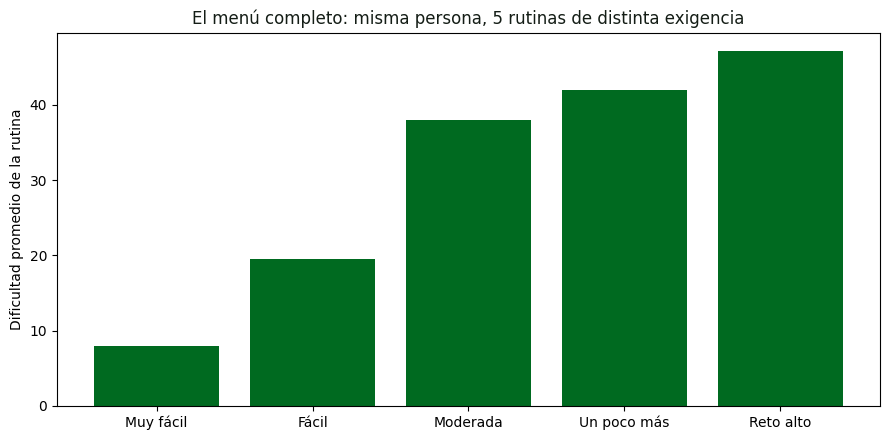

El desplazamiento es PROPORCIONAL a la distancia disponible en cada extremo —
así 'Reto alto' siempre toca el techo real, sin importar cuánto haya crecido por feedback.


In [18]:

POSICIONES_MENU = [
    ("Muy fácil", -1.0, PESO_BALANCE_ZONAS_DEFAULT),
    ("Fácil", -0.6, PESO_BALANCE_ZONAS_DEFAULT),
    ("Moderada", 0.0, PESO_BALANCE_ZONAS_DEFAULT),
    ("Un poco más", 0.35, PESO_BALANCE_ZONAS_DEFAULT),
    ("Reto alto", 0.7, PESO_BALANCE_ZONAS_DEFAULT),
]


def generar_menu(equipo_disponible, objetivo, nivel_cluster_nombre, historial=None):
    rango = RANGO_DIFICULTAD_POR_CLUSTER.get(nivel_cluster_nombre, RANGO_DEFAULT_SIN_CLASIFICACION)
    nivel_base = (rango[0] + rango[1]) / 2 + calcular_ajuste_dificultad(historial)
    techo = calcular_tope_dificultad(nivel_cluster_nombre, historial)
    piso = rango[0]

    variantes = []
    for etiqueta, posicion, peso_balance in POSICIONES_MENU:
        desplazamiento = posicion * (nivel_base - piso) if posicion <= 0 else posicion * (techo - nivel_base)
        variante = generar_rutina(
            equipo_disponible, objetivo, nivel_cluster_nombre, historial,
            desplazamiento_dificultad=desplazamiento, peso_balance=peso_balance, etiqueta=etiqueta,
        )
        if variante["ejercicios"]:
            variantes.append(variante)
    return variantes


menu_demo = generar_menu(equipo_usuario, "Ganar músculo", "Contextura Ligera, Buena Eficiencia")

fig, ax = plt.subplots()
etiquetas = [v["etiqueta"] for v in menu_demo]
dificultades = [v["dificultad_promedio_rutina"] for v in menu_demo]
ax.bar(etiquetas, dificultades, color=VERDE_PRIMARIO)
ax.set_ylabel("Dificultad promedio de la rutina")
ax.set_title("El menú completo: misma persona, 5 rutinas de distinta exigencia", color=CASI_NEGRO)
plt.tight_layout()
plt.show()

print("El desplazamiento es PROPORCIONAL a la distancia disponible en cada extremo —")
print("así 'Reto alto' siempre toca el techo real, sin importar cuánto haya crecido por feedback.")



## Conclusiones

1. La métrica de score (distancia absoluta, no producto punto) es lo
   que hace que este sistema funcione donde la similitud coseno
   fallaba — penaliza pasarse de dificultad, no solo premia acercarse.
2. El tope progresivo + rango de cluster + ajuste por feedback dan
   personalización real sin necesitar reentrenar nada: son puros
   parámetros que mueven la misma función de score.
3. El balance de zonas evita que el sistema "castigue" para siempre a
   una zona solo porque el objetivo declarado no la prioriza.
4. Generar el menú completo (5 variantes) con el mismo motor, solo
   variando el desplazamiento de dificultad, es mucho más simple que
   mantener 5 modelos o 5 reglas distintas.
